In [5]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import numpy as np

from utils import DataGenerator

In [6]:
# Setup a simulation of a 2D scattering problem
E_0 = 1
k_0 = 1
scatterers = np.array([[3,1], [2,7]])

sim_config = {"simulation_type": "scattered_field",
              "E_0": E_0,
              "k_0": k_0,
              "propagation_angle": 0,    # angle of the incoming wave - 0 is left to right
              "scatterers": scatterers}

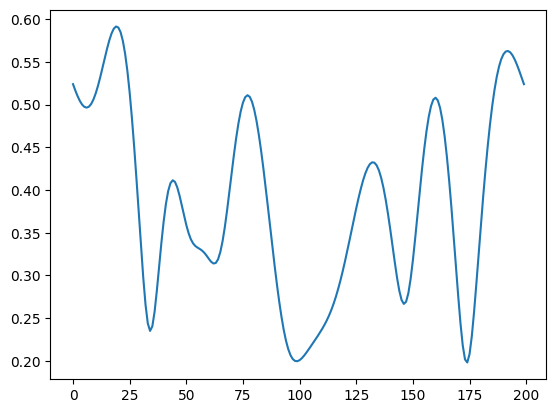

In [9]:
# Generate a dataset along the circumference of a circle
num_points = 200
center = np.array([0, 0])
radius = 5

sim = DataGenerator(sim_config)
output_field_curve = sim.generate_radial_dataset(center, radius, num_points)
plt.plot(np.arange(0, num_points, 1), np.abs(output_field_curve))

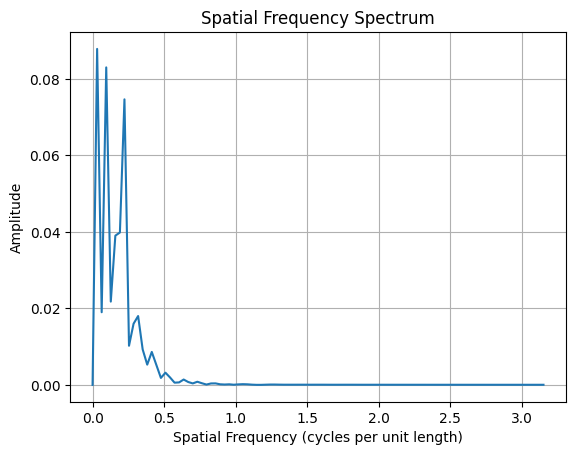

In [10]:
# Apply a fourier transform to the spatial data to get the spatial frequency spectrum

circumference = 2 * np.pi * radius 

# Spatial sampling interval
delta_s = circumference / num_points

# Apply Fourier Transform to the spatial data
yf = fft(np.abs(output_field_curve))

# Zero out the DC component
yf[0] = 0

# Generate spatial frequency bins
xf = fftfreq(num_points, delta_s)[:num_points//2]

# Plot the spatial frequency spectrum
plt.plot(xf, 2.0/num_points * np.abs(yf[0:num_points//2]))
plt.title('Spatial Frequency Spectrum')
plt.xlabel('Spatial Frequency (cycles per unit length)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()